## **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import joblib

## **Load the dataset**

In [2]:
df = pd.read_csv("Dataset.csv")

df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


## **Basic inspection**

In [3]:
print("Shape:", df.shape)

df.info()

Shape: (8790, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
show_id,8790,8790,s8786,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,8790,2,Movie,6126,NaN,NaN,NaN,NaN,NaN,NaN,NaN
title,8790,8787,9-Feb,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
director,8790,4528,Not Given,2588,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,8790,86,United States,3240,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_added,8790,1713,1/1/2020,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
release_year,8790.0,NaN,NaN,NaN,2014.183163,8.825466,1925.0,2013.0,2017.0,2019.0,2021.0
rating,8790,14,TV-MA,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration,8790,220,1 Season,1791,NaN,NaN,NaN,NaN,NaN,NaN,NaN
listed_in,8790,513,"Dramas, International Movies",362,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
country,0
date_added,0
release_year,0
rating,0
duration,0
listed_in,0


## **Initial Exploration**

### **Target distribution**

In [6]:
df["type"].value_counts()

,count
type,
Movie,6126
TV Show,2664


In [7]:
df["type"].value_counts(normalize=True) * 100

,proportion
type,
Movie,69.692833
TV Show,30.307167


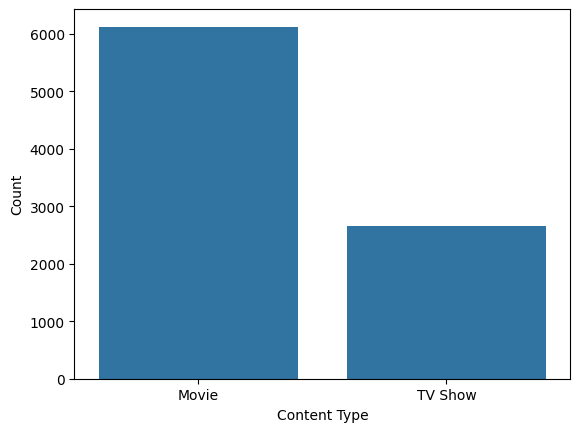

In [8]:
sns.countplot(data=df, x="type")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.show()

### **Unique values**

In [9]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].nunique())


show_id:
8790

type:
2

title:
8787

director:
4528

country:
86

date_added:
1713

release_year:
74

rating:
14

duration:
220

listed_in:
513


## **Data Cleaning**

### **Drop unnecessary columns**

In [10]:
df = df.drop(columns=["show_id", "title", "country"])

### **Date Format**

In [11]:
df["date_added"] = pd.to_datetime(df["date_added"])

### **Inspecting Duration for Target Leakage**

In [12]:
df["duration"].value_counts().head(20)

,count
duration,
1 Season,1791
2 Seasons,421
3 Seasons,198
90 min,152
94 min,146
97 min,146
93 min,146
91 min,144
95 min,137


In [13]:
df.groupby("type")["duration"].apply(
    lambda x: x.dropna().astype(str).str.extract(r"([A-Za-z]+)$")[0].value_counts()
)

type     0      
Movie    min        6126
TV Show  Season     1791
         Seasons     873
Name: duration, dtype: int64

In [14]:
df = df.drop(columns=["duration"])

Due to target leakage problem, dropped `duration` column.

## **Feature Engineering**

### **Extract date features**

In [15]:
df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

In [16]:
# Drop 'date_added' column
df = df.drop(columns=["date_added"])

In [17]:
df.head()

,type,director,release_year,rating,listed_in,year_added,month_added
0,Movie,Kirsten Johnson,2020,PG-13,Documentaries,2021,9
1,TV Show,Julien Leclercq,2021,TV-MA,"Crime TV Shows, International TV Shows, TV Act...",2021,9
2,TV Show,Mike Flanagan,2021,TV-MA,"TV Dramas, TV Horror, TV Mysteries",2021,9
3,Movie,Bruno Garotti,2021,TV-PG,"Children & Family Movies, Comedies",2021,9
4,Movie,Haile Gerima,1993,TV-MA,"Dramas, Independent Movies, International Movies",2021,9


## **Separate X and y**

In [18]:
X = df.drop(columns=["type"])
y = df["type"]

In [19]:
X.shape, y.shape

((8790, 6), (8790,))

## **Train/Test Split**

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
# Encoding 'director' and 'rating'
categorical_features = ["director", "rating"]

numeric_features = [
    "release_year",
    "year_added",
    "month_added"
]

In [22]:
def split_genres_func(text):
    return text.split(", ")

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "genres",
            CountVectorizer(
                tokenizer=split_genres_func,
                token_pattern=None
            ),
            "listed_in"
        )
    ]
)

## **Logistic Regression**

In [23]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [24]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['director', 'rating']),
                                                 ('numeric', StandardScaler(),
                                                  ['release_year', 'year_added',
                                                   'month_added']),
                                                 ('genres',
                                                  CountVectorizer(token_pattern=None,
                                                                  tokenizer=<function split_genres_func at 0x7ee00228a3e0>),
                                                  'listed_in')])),
                ('classifier', LogisticRegression(max_iter=1000))])

In [25]:
y_pred = model.predict(X_test)

### **Final evaluation**

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       Movie       1.00      1.00      1.00      1225
     TV Show       1.00      1.00      1.00       533

    accuracy                           1.00      1758
   macro avg       1.00      1.00      1.00      1758
weighted avg       1.00      1.00      1.00      1758



In [27]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="TV Show"))
print("Recall:", recall_score(y_test, y_pred, pos_label="TV Show"))
print("F1 Score:", f1_score(y_test, y_pred, pos_label="TV Show"))

Accuracy: 0.9988623435722411
Precision: 1.0
Recall: 0.9962476547842402
F1 Score: 0.9981203007518797


### **Confusion Matrix**

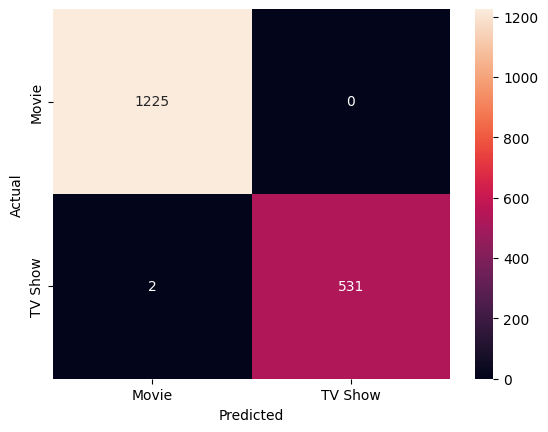

In [28]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Movie", "TV Show"]
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Movie", "TV Show"],
    yticklabels=["Movie", "TV Show"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## **Model Selection and Feature Considerations**

Logistic Regression was selected as the final model because it achieved excellent performance on the test set, with an accuracy of approximately 99.89% and only two misclassified samples. The dataset appears to be relatively easy for this binary classification task, particularly because the `listed_in` genre information provides strong signals for distinguishing Movies from TV Shows.

The `duration` column was excluded because its unit directly reveals the content type (`minutes` for Movies and `seasons` for TV Shows), which would introduce target leakage. The `country` column was also excluded because a large portion of its values were missing or considered unreliable. `show_id` and `title` were excluded because they were not considered useful or appropriate predictive features.

Additional experiments showed that removing `director` or `rating` produced essentially the same performance, suggesting that the model's strong results are mainly driven by the available metadata, particularly the genre information. The high test-set performance does not by itself prove the absence of overfitting, but there is no obvious indication of severe overfitting from my evaluation.

## **Save the model**

In [30]:
joblib.dump(model, "netflix_content_classifier.pkl")

['netflix_content_classifier.pkl']